# Pressure Vessels


The hoop strength, or circumferential stress (C, expressed in MPa), to which a cylindrical vessel is exposed is given by the following equation:

               C = P*R/W

where:
    P is the internal pressure in the vessel (a gauge pressure, expressed in MPa)
    R is the inside radius of the pipe, expressed in mm
    W is wall thickness, expressed in mm

We will make the following assumptions concerning the distribution of our input variables:
    1) pipe radius R follows a normal distribution with a mean of 50 mm and coefficient of variation (COV) of 0.05;
    2) wall thickness W follows a normal distribution with a mean of 5 mm and COV of 0.05;
    3) yield strength Y is also a random variable, following a normal distribution with a mean of 200 MPa and COV of 0.1;
    4) internal pressure in the vessel is assumed to be constant at 15 MPa.

Use a Monte Carlo simulation to estimate the probability of failure, which arises when the stress exceeds the yield strength of the vessel.

In [1]:
# In this simulation the library numpy is used and it is named it "np"
# We will also use the matplotlib.pyplot and we will name it plt

import numpy as np
import matplotlib.pyplot as plt

# The seed below initializes the random generator to always obtain the same random inputs. 
# DO NOT CHANGE THIS VALUE AND RERUN THIS CELL EVERYTIME YOU RUN THE PROGRAM. 
np.random.seed(3500) 

In [2]:
# Variables are defined in this cell 

mean_R = 50           # Mean of pipe radius
std_R = 50*0.05       # Standard deviation of pipe radius
mean_W = 5            # Mean of wall thickness
std_W = 5*0.05        # Standard deviation of wall thickness
mean_Y = 200          # Mean of yield strength
std_Y = 200*0.1       # Standard deviation of yield strength

R = []                # Empty list to store pipe radius
W = []                # Empty list to store wall thickness
C = []                # Empty list to store hoop strength
Y = []                # Empty list to store yield strength

nFailures = 0  # Counter of failures
pFailures = 0  # Probability of failure

# Monte Carlo simulation
nsim = 100000   # Number of simulation 

In [3]:

for i in range(nsim):
    P = 15                # Internal pressure in the vessel in MPa

    # Generate pipe radius
    R.append(np.random.normal(mean_R, std_R))
    # Generate wall thickness
    W.append(np.random.normal(mean_W, std_W))

    # Calculate hoop strength
    C.append(P * R[i] / W[i])

    # Generate yield strength
    Y.append(np.random.normal(mean_Y, std_Y))

    # Check for failure
    if C[i] > Y[i]:
        nFailures = nFailures + 1

# Calculate the probability of failure
pFailures = nFailures / nsim

print("The probability of failure is ", pFailures)

The probability of failure is  0.0146


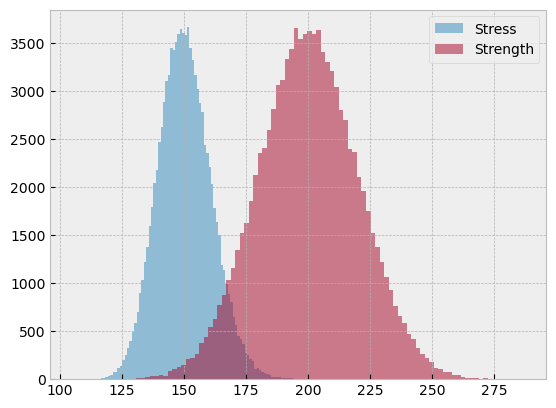

In [4]:
plt.style.use("bmh")
plt.hist(C, bins=100, alpha=0.5, label="Stress")
plt.hist(Y, bins=100, alpha=0.5, label="Strength")
plt.legend(loc="upper right");